# Tri-VAE: Unsupervised Anomaly Detection on IXI Brain MRI
**Architecture**: Triplet VAE + Gated Cross Skip (GCS) connections  
**Dataset**: IXI2D — 25k+ healthy 2D axial brain MRI slices  
**Strategy**: Train on healthy only → anomalies appear as reconstruction residuals  

**Why NOT full U-Net skips?**  
Full skips let the decoder copy texture bypassing the bottleneck — anomalies get reconstructed too, making them invisible.  
Tri-VAE uses GCS (gated cosine-similarity skip) only in shallow layers, suppressing anomalous regions.

## Cell 1 — Install dependencies

In [1]:
!pip install torch torchvision matplotlib scikit-learn scipy tqdm Pillow -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Found existing installation: torchvision 0.25.0
Uninstalling torchvision-0.25.0:
  Successfully uninstalled torchvision-0.25.0
Found existing installation: torchaudio 2.10.0+cu126
Uninstalling torchaudio-2.10.0+cu126:
  Successfully uninstalled torchaudio-2.10.0+cu126


You can safely remove it manually.


In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
   ---------------------------------------- 0.0/2.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 GB 7.9 MB/s eta 0:06:02
   ---------------------------------------- 0.0/2.9 GB 11.5 MB/s eta 0:04:09
   ---------------------------------------- 0.0/2.9 GB 18.5 MB/s eta 0:02:35
   ---------------------------------------- 0.0/2.9 GB 17.0 MB/s eta 0:02:49
   ---------------------------------------- 0.0/2.9 GB 15.9 MB/s eta 0:03:00
   ---------------------------------------- 0.0/2.9 GB 15.6 MB/s eta 0:03:04
   ---------------------------------------- 0.0/2.9 GB 15.6 MB/s eta 0:03:04
   ---------------------------------------- 0.0/2.9 GB 17.0 MB/s eta 0:02:49
   ---------------------------------------- 0.0/2.9 GB 19.6 MB/s eta 0:02:26
   ---------------------------------------- 0.0/2.9 GB 21.3 MB/s eta 0:02:15
   ---------------------------------------- 0.0/2.9 GB 25.2 MB/s eta 0:01:54
   -----------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Imports & reproducibility

In [5]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Fri Mar 13 15:03:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.83                 Driver Version: 576.83         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090      WDDM  |   00000000:01:00.0 Off |                  Off |
|  0%   38C    P8              2W /  450W |     382MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
NVIDIA GeForce RTX 4090


In [1]:
import os, random, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4090


## Cell 3 — Config (change paths here)

In [2]:
# ── YOUR FOLDER STRUCTURE ──────────────────────────────────────────
# Dataset-ixi/
#   train/train/   ← actual images live here (ignore _MACOSX)
#   valid/valid/   ← actual images live here
# ──────────────────────────────────────────────────────────────────

TRAIN_DIR = Path('Dataset-ixi/train/train')    # adjust if needed
VALID_DIR = Path('Dataset-ixi/valid/valid')    # adjust if needed

IMG_SIZE    = 128      # start with 128×128; change to 256 if you have ≥8GB VRAM
BATCH_SIZE  = 120   # reduce to 8 if OOM
LATENT_DIM  = 512      # bottleneck size
BASE_CH     = 32       # channel multiplier (32→64→128→256→512)
EPOCHS      = 100
LR          = 1e-4
KLD_WEIGHT  = 1e-4     # β in β-VAE; small keeps reconstruction sharp
TRIPLET_M   = 1.0      # triplet loss margin α
NOISE_STD   = 0.2      # coarse noise σ (paper: 16×16 @ σ=0.2)
NOISE_RES   = 16       # coarse noise resolution before upsampling
SSIM_WEIGHT = 0.5
SAVE_DIR    = Path('checkpoints')
SAVE_DIR.mkdir(exist_ok=True)

print('Config set. Train dir exists:', TRAIN_DIR.exists())
print('Valid dir exists:', VALID_DIR.exists())

Config set. Train dir exists: True
Valid dir exists: True


## Cell 4 — Dataset & triplet dataloader

In [3]:
def get_image_paths(folder: Path):
    """Recursively collect all images, skipping __MACOSX."""
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    paths = []
    for p in sorted(folder.rglob('*')):
        if '__MACOSX' in str(p):
            continue
        if p.suffix.lower() in exts and p.is_file():
            paths.append(p)
    return paths


class IXITripletDataset(Dataset):
    """
    Returns (anchor, positive, negative_noisy) for Tri-VAE training.
    anchor   = healthy slice i
    positive = a DIFFERENT healthy slice j  (i != j)
    negative = anchor + injected coarse noise  (simulates lesion)
    """
    def __init__(self, folder: Path, img_size: int = 128,
                 noise_std: float = 0.2, noise_res: int = 16):
        self.paths      = get_image_paths(folder)
        self.noise_std  = noise_std
        self.noise_res  = noise_res
        self.img_size   = img_size
        assert len(self.paths) > 0, f'No images found in {folder}'

        self.tf = T.Compose([
            T.Grayscale(1),
            T.Resize((img_size, img_size)),
            T.ToTensor(),               # [0,1]
            T.Normalize([0.5], [0.5]),  # → [-1,1]
        ])

    def _coarse_noise(self, img: torch.Tensor) -> torch.Tensor:
        """Low-resolution noise upsampled to IMG_SIZE — simulates lesion blobs."""
        _, H, W = img.shape
        noise = torch.randn(1, 1, self.noise_res, self.noise_res) * self.noise_std
        noise = F.interpolate(noise, size=(H, W), mode='bilinear',
                              align_corners=False).squeeze(0)
        return (img + noise).clamp(-1, 1)

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        anchor = self.tf(Image.open(self.paths[idx]).convert('RGB'))

        # positive: a different random healthy slice
        pos_idx = idx
        while pos_idx == idx:
            pos_idx = random.randint(0, len(self.paths) - 1)
        positive = self.tf(Image.open(self.paths[pos_idx]).convert('RGB'))

        # negative: anchor + coarse noise
        negative = self._coarse_noise(anchor.clone())

        return anchor, positive, negative


class IXIValDataset(Dataset):
    """Validation: returns (image, label) — 0=healthy, 1=synthetic anomaly."""
    def __init__(self, folder: Path, img_size: int = 128,
                 noise_std: float = 0.2, noise_res: int = 16):
        self.paths     = get_image_paths(folder)
        self.noise_std = noise_std
        self.noise_res = noise_res
        self.tf = T.Compose([
            T.Grayscale(1),
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]),
        ])

    def _coarse_noise(self, img):
        _, H, W = img.shape
        noise = torch.randn(1, 1, self.noise_res, self.noise_res) * self.noise_std
        noise = F.interpolate(noise, size=(H, W), mode='bilinear',
                              align_corners=False).squeeze(0)
        return (img + noise).clamp(-1, 1)

    def __len__(self): return len(self.paths) * 2

    def __getitem__(self, idx):
        real_idx   = idx % len(self.paths)
        is_anomaly = idx >= len(self.paths)
        img = self.tf(Image.open(self.paths[real_idx]).convert('RGB'))
        if is_anomaly:
            img = self._coarse_noise(img)
        return img, int(is_anomaly)


train_ds = IXITripletDataset(TRAIN_DIR, IMG_SIZE, NOISE_STD, NOISE_RES)
val_ds   = IXIValDataset(VALID_DIR,   IMG_SIZE, NOISE_STD, NOISE_RES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds):,} slices  |  Triplet batches: {len(train_loader)}')
print(f'Val  : {len(val_ds):,} samples  (50% healthy / 50% synthetic anomaly)')

Train: 25,447 slices  |  Triplet batches: 213
Val  : 5,656 samples  (50% healthy / 50% synthetic anomaly)


## Cell 5 — Visualise a triplet batch

In [ ]:
def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1).cpu()

anchor, positive, negative = next(iter(train_loader))
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
titles = ['Anchor (healthy)', 'Positive (healthy)', 'Negative (noisy)']
for row, (imgs, title) in enumerate(zip([anchor, positive, negative], titles)):
    for col in range(6):
        axes[row, col].imshow(denorm(imgs[col]).squeeze(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(title, fontsize=10)
plt.suptitle('Triplet samples — each column is one training triplet', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 6 — Tri-VAE model
**Architecture choices:**
- Encoder: 5 conv blocks (stride-2), channels 1→32→64→128→256→512
- Bottleneck: FC → μ, logσ² → reparameterise → FC → reshape
- Decoder: 5 transposed conv blocks (mirror encoder)
- **GCS skip**: only on first 3 shallow encoder↔decoder pairs
- Deep layers (4,5): NO skip — forces bottleneck to learn brain distribution

In [4]:
# ── Building block ─────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.SiLU(),
        )
    def forward(self, x): return self.net(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x): return self.conv(self.up(x))


# ── Gated Cross Skip (GCS) ─────────────────────────────────────────
class GatedCrossSkip(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        r = max(ch // reduction, 8)
        self.enc_proj = nn.Linear(ch, r, bias=False)
        self.dec_proj = nn.Linear(ch, r, bias=False)
        self.alpha = nn.Parameter(torch.zeros(1))
        self.beta  = nn.Parameter(torch.ones(1))
        self.out   = nn.Conv2d(ch * 2, ch, 1, bias=False)

    def forward(self, enc_feat, dec_feat):
        # align spatial size if different
        if enc_feat.shape[2:] != dec_feat.shape[2:]:
            enc_feat = F.interpolate(enc_feat, size=dec_feat.shape[2:],
                                     mode='bilinear', align_corners=False)
        # align channels if different — just return dec unchanged
        if enc_feat.shape[1] != dec_feat.shape[1]:
            return dec_feat

        B, C, H, W = dec_feat.shape
        ep = enc_feat.mean(dim=[2, 3])            # (B, C)
        dp = dec_feat.mean(dim=[2, 3])            # (B, C)
        e  = F.normalize(self.enc_proj(ep), dim=-1)
        d  = F.normalize(self.dec_proj(dp), dim=-1)
        gate = torch.tanh((e * d).sum(dim=-1, keepdim=True)).view(B, 1, 1, 1)
        gated_enc = gate * enc_feat
        fused = torch.cat([self.alpha * gated_enc, self.beta * dec_feat], dim=1)
        return self.out(fused)


# ── Tri-VAE ────────────────────────────────────────────────────────
class TriVAE(nn.Module):
    def __init__(self, img_size=128, latent_dim=512, base_ch=32):
        super().__init__()
        self.img_size   = img_size
        self.latent_dim = latent_dim
        ch = [1, base_ch, base_ch*2, base_ch*4, base_ch*8, base_ch*16]
        # ch = [1, 32, 64, 128, 256, 512]

        # ── Encoder ──────────────────────────────────────────────
        self.enc1 = ConvBlock(ch[0], ch[1], stride=2)  # 128→64,  out: 32ch
        self.enc2 = ConvBlock(ch[1], ch[2], stride=2)  # 64→32,   out: 64ch
        self.enc3 = ConvBlock(ch[2], ch[3], stride=2)  # 32→16,   out: 128ch
        self.enc4 = ConvBlock(ch[3], ch[4], stride=2)  # 16→8,    out: 256ch
        self.enc5 = ConvBlock(ch[4], ch[5], stride=2)  # 8→4,     out: 512ch

        # dynamically compute flat size
        with torch.no_grad():
            _d = torch.zeros(1, 1, img_size, img_size)
            _d = self.enc5(self.enc4(self.enc3(self.enc2(self.enc1(_d)))))
            self.flat_size  = int(_d.numel())
            self.spatial_h  = _d.shape[2]
            self.spatial_w  = _d.shape[3]
            self.enc_out_ch = _d.shape[1]
        print(f'Encoder output: {_d.shape} → flat={self.flat_size}')

        self.fc_mu     = nn.Linear(self.flat_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_size, latent_dim)

        # ── Decoder ──────────────────────────────────────────────
        self.fc_dec = nn.Linear(latent_dim, self.flat_size)

        self.dec5 = UpBlock(ch[5], ch[4])   # 4→8,   512→256
        self.dec4 = UpBlock(ch[4], ch[3])   # 8→16,  256→128
        self.dec3 = UpBlock(ch[3], ch[2])   # 16→32, 128→64
        self.coarse_out = nn.Conv2d(ch[2], 1, 1)  # 64ch→1ch at 32×32

        # GCS: channels must match decoder output at that stage
        self.gcs3 = GatedCrossSkip(ch[2])   # 64ch  (after dec3)
        self.gcs2 = GatedCrossSkip(ch[1])   # 32ch  (after dec2)
        self.gcs1 = GatedCrossSkip(ch[1])   # 32ch  (after dec1)

        self.dec2  = UpBlock(ch[2], ch[1])  # 32→64,  64→32ch
        self.dec1  = UpBlock(ch[1], ch[1])  # 64→128, 32→32ch

        self.final = nn.Sequential(
            nn.Conv2d(ch[1], ch[0], 3, padding=1),  # 32→1
            nn.SiLU(),
            nn.Conv2d(ch[0], 1, 1),
            nn.Tanh()
        )

    def encode(self, x):
        e1 = self.enc1(x)   # (B, 32,  64, 64)
        e2 = self.enc2(e1)  # (B, 64,  32, 32)
        e3 = self.enc3(e2)  # (B, 128, 16, 16)
        e4 = self.enc4(e3)  # (B, 256,  8,  8)
        e5 = self.enc5(e4)  # (B, 512,  4,  4)
        flat = e5.view(e5.size(0), -1)
        mu     = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        return mu, logvar, (e1, e2, e3)

    def reparameterise(self, mu, logvar):
        if self.training:
            std = (0.5 * logvar).exp()
            return mu + std * torch.randn_like(std)
        return mu

    def decode(self, z, enc_skips=None):
        x = self.fc_dec(z)
        x = x.view(x.size(0), self.enc_out_ch, self.spatial_h, self.spatial_w)

        x = self.dec5(x)          # (B, 256, 8,  8)
        x = self.dec4(x)          # (B, 128, 16, 16)
        x = self.dec3(x)          # (B, 64,  32, 32)
        coarse = self.coarse_out(x)  # (B, 1,  32, 32) — semantic loss

        # GCS3: enc3=(B,128,16,16) but dec is (B,64,32,32) → channels differ → passthrough
        if enc_skips is not None:
            x = self.gcs3(enc_skips[2], x)

        x = self.dec2(x)          # (B, 32, 64, 64)

        # GCS2: enc2=(B,64,32,32), dec=(B,32,64,64) → spatial+ch differ → passthrough
        if enc_skips is not None:
            x = self.gcs2(enc_skips[1], x)

        x = self.dec1(x)          # (B, 32, 128, 128)

        # GCS1: enc1=(B,32,64,64), dec=(B,32,128,128) → spatial differs → resize+gate
        if enc_skips is not None:
            x = self.gcs1(enc_skips[0], x)

        return self.final(x), coarse

    def forward(self, x):
        mu, logvar, enc_skips = self.encode(x)
        z = self.reparameterise(mu, logvar)
        recon, coarse = self.decode(z, enc_skips)
        return recon, coarse, mu, logvar


# ── Build model ───────────────────────────────────────────────────
model = TriVAE(IMG_SIZE, LATENT_DIM, BASE_CH).to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tri-VAE parameters: {params/1e6:.2f}M')

# ── Sanity check forward pass ─────────────────────────────────────
with torch.no_grad():
    _x = torch.zeros(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _r, _c, _mu, _lv = model(_x)
    print(f'Input:   {_x.shape}')
    print(f'Recon:   {_r.shape}')
    print(f'Coarse:  {_c.shape}')
    print(f'Mu:      {_mu.shape}')
    print('Sanity check passed ✓')

Encoder output: torch.Size([1, 512, 4, 4]) → flat=8192
Tri-VAE parameters: 19.69M
Input:   torch.Size([2, 1, 128, 128])
Recon:   torch.Size([2, 1, 128, 128])
Coarse:  torch.Size([2, 1, 32, 32])
Mu:      torch.Size([2, 512])
Sanity check passed ✓


## Cell 7 — Loss functions

In [5]:
def kld_loss(mu, logvar):
    """KL divergence: q(z|x) || N(0,I)"""
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def triplet_loss(anc_mu, pos_mu, neg_mu, margin=1.0):
    """
    d(anc,pos) < d(anc,neg) + margin
    Computed on bottleneck embeddings (mu vectors).
    """
    d_pos = ((anc_mu - pos_mu) ** 2).sum(dim=1)
    d_neg = ((anc_mu - neg_mu) ** 2).sum(dim=1)
    return F.relu(d_pos - d_neg + margin).mean()


def ssim_loss(x, y, C1=0.01**2, C2=0.03**2):
    """
    1 - SSIM: structural similarity loss.
    Applied on neg reconstruction to push structural
    similarity toward the clean (pre-noise) version.
    """
    mu_x  = F.avg_pool2d(x, 3, 1, 1)
    mu_y  = F.avg_pool2d(y, 3, 1, 1)
    sx    = F.avg_pool2d(x*x, 3, 1, 1) - mu_x**2
    sy    = F.avg_pool2d(y*y, 3, 1, 1) - mu_y**2
    sxy   = F.avg_pool2d(x*y, 3, 1, 1) - mu_x*mu_y
    num   = (2*mu_x*mu_y + C1) * (2*sxy + C2)
    den   = (mu_x**2 + mu_y**2 + C1) * (sx + sy + C2)
    return 1 - (num / den.clamp(min=1e-8)).mean()


def trivae_loss(model, anc, pos, neg,
                kld_w=KLD_WEIGHT, trip_m=TRIPLET_M, ssim_w=SSIM_WEIGHT):
    """
    Total loss = L1_total + KLD(anc+pos) + Triplet + SSIM(neg)
    Matches Equation (8) in the Tri-VAE paper.
    """
    # Forward pass for all three
    ra, ca, mu_a, lv_a = model(anc)
    rp, cp, mu_p, lv_p = model(pos)
    rn, cn, mu_n, lv_n = model(neg)

    # L1 reconstruction loss
    # Paper: L1 at 32×32 for all three; L1 at 256×256 only for neg
    target_coarse_a = F.interpolate(anc, size=ca.shape[2:], mode='bilinear', align_corners=False)
    target_coarse_p = F.interpolate(pos, size=cp.shape[2:], mode='bilinear', align_corners=False)
    target_coarse_n = F.interpolate(neg, size=cn.shape[2:], mode='bilinear', align_corners=False)

    l1_coarse = (F.l1_loss(ca, target_coarse_a) +
                 F.l1_loss(cp, target_coarse_p) +
                 F.l1_loss(cn, target_coarse_n))
    l1_full   = F.l1_loss(rn, anc)   # neg recon vs clean anchor (teach to denoise)
    l1_total  = l1_coarse + l1_full

    # KLD: anchor + positive only (not negative — we want neg projected to healthy)
    kld = kld_w * (kld_loss(mu_a, lv_a) + kld_loss(mu_p, lv_p))

    # Triplet on bottleneck embeddings
    trip = triplet_loss(mu_a, mu_p, mu_n, margin=trip_m)

    # SSIM on negative reconstruction vs clean anchor
    ssim = ssim_w * ssim_loss(rn, anc)

    total = l1_total + kld + trip + ssim
    return total, dict(l1=l1_total.item(), kld=kld.item(),
                       trip=trip.item(), ssim=ssim.item())

print('Loss functions defined.')

Loss functions defined.


## Cell 8 — Training loop

In [6]:
import csv
import torch
import time

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {k: [] for k in ['loss','l1','kld','trip','ssim']}
best_loss = float('inf')

# ── Resume from checkpoint ────────────────────────────────────────
RESUME = SAVE_DIR / 'trivae_latest.pt'
start_epoch = 1
best_loss = float('inf')

if RESUME.exists():
    ckpt = torch.load(RESUME, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optim'])
    scheduler.load_state_dict(ckpt['scheduler'])
    history     = ckpt['history']
    start_epoch = ckpt['epoch'] + 1
    best_loss   = ckpt['loss']
    print(f'Resumed from epoch {ckpt["epoch"]}, loss={best_loss:.4f}')

# ── CSV log setup ─────────────────────────────────────────────────
LOG_CSV = SAVE_DIR / 'trivae_training_log.csv'
csv_fields = ['epoch','loss','l1','kld','trip','ssim',
              'epoch_time_sec','lr',
              'vram_used_mb','vram_total_mb','vram_pct',
              'best_loss','is_best']

# Write header only if starting fresh
if not LOG_CSV.exists() or start_epoch == 1:
    with open(LOG_CSV, 'w', newline='') as f:
        csv.DictWriter(f, fieldnames=csv_fields).writeheader()

print(f'Logging to {LOG_CSV}')

# ── Training loop ─────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    run = {k: 0.0 for k in ['loss','l1','kld','trip','ssim']}
    t0  = time.time()

    for anc, pos, neg in tqdm(train_loader,
                               desc=f'Epoch {epoch:3d}/{EPOCHS}',
                               leave=False):
        anc, pos, neg = anc.to(DEVICE), pos.to(DEVICE), neg.to(DEVICE)
        optimizer.zero_grad()
        loss, parts = trivae_loss(model, anc, pos, neg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        run['loss'] += loss.item()
        for k, v in parts.items():
            run[k] += v

    scheduler.step()
    epoch_time = time.time() - t0

    n = len(train_loader)
    for k in run:
        history[k].append(run[k] / n)

    epoch_loss = history['loss'][-1]
    current_lr = optimizer.param_groups[0]['lr']

    # ── VRAM stats ────────────────────────────────────────────────
    if DEVICE == 'cuda':
        vram_used  = torch.cuda.memory_allocated(0) / 1024**2
        vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**2
        vram_pct   = (vram_used / vram_total) * 100
        torch.cuda.reset_peak_memory_stats(0)
    else:
        vram_used = vram_total = vram_pct = 0.0

    # ── Console print ─────────────────────────────────────────────
    is_best = epoch_loss < best_loss
    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Loss={epoch_loss:.4f}  '
          f'L1={history["l1"][-1]:.4f}  '
          f'KLD={history["kld"][-1]:.4f}  '
          f'Trip={history["trip"][-1]:.4f}  '
          f'SSIM={history["ssim"][-1]:.4f}  | '
          f'VRAM={vram_used:.0f}/{vram_total:.0f}MB ({vram_pct:.1f}%)  '
          f'LR={current_lr:.2e}  '
          f'Time={epoch_time:.1f}s'
          + ('  ✓ best' if is_best else ''))

    # ── CSV log ───────────────────────────────────────────────────
    with open(LOG_CSV, 'a', newline='') as f:
        csv.DictWriter(f, fieldnames=csv_fields).writerow({
            'epoch':          epoch,
            'loss':           round(epoch_loss, 6),
            'l1':             round(history['l1'][-1], 6),
            'kld':            round(history['kld'][-1], 6),
            'trip':           round(history['trip'][-1], 6),
            'ssim':           round(history['ssim'][-1], 6),
            'epoch_time_sec': round(epoch_time, 2),
            'lr':             round(current_lr, 8),
            'vram_used_mb':   round(vram_used, 1),
            'vram_total_mb':  round(vram_total, 1),
            'vram_pct':       round(vram_pct, 2),
            'best_loss':      round(best_loss if not is_best else epoch_loss, 6),
            'is_best':        is_best,
        })

    # ── Rolling checkpoint ────────────────────────────────────────
    torch.save({
        'epoch':     epoch,
        'model':     model.state_dict(),
        'optim':     optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'history':   history,
        'loss':      epoch_loss,
    }, SAVE_DIR / 'trivae_latest.pt')

    # ── Best model ────────────────────────────────────────────────
    if is_best:
        best_loss = epoch_loss
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'optim':     optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'history':   history,
            'loss':      best_loss,
        }, SAVE_DIR / 'trivae_best.pt')

print(f'\nTraining complete. Best loss: {best_loss:.4f}')
print(f'Full log saved to: {LOG_CSV}')

Logging to checkpoints\trivae_training_log.csv


Epoch   1/100:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch   1/100 | Loss=2.3752  L1=1.5365  KLD=0.0003  Trip=0.2276  SSIM=0.6107  | VRAM=323/24564MB (1.3%)  LR=1.00e-04  Time=114.0s  ✓ best


Epoch   2/100 | Loss=1.1625  L1=0.8602  KLD=0.0005  Trip=0.0073  SSIM=0.2944  | VRAM=323/24564MB (1.3%)  LR=9.99e-05  Time=70.1s  ✓ best


Epoch   3/100 | Loss=0.7280  L1=0.5399  KLD=0.0005  Trip=0.0077  SSIM=0.1799  | VRAM=323/24564MB (1.3%)  LR=9.98e-05  Time=72.9s  ✓ best


...

Epoch  67/100 | Loss=0.2575  L1=0.2081  KLD=0.0007  Trip=0.0061  SSIM=0.0427  | VRAM=323/24564MB (1.3%)  LR=2.45e-05  Time=69.2s


Epoch  68/100 | Loss=0.2477  L1=0.2047  KLD=0.0007  Trip=0.0000  SSIM=0.0423  | VRAM=323/24564MB (1.3%)  LR=2.32e-05  Time=69.1s  ✓ best


Epoch  69/100 | Loss=0.2468  L1=0.2039  KLD=0.0007  Trip=0.0000  SSIM=0.0422  | VRAM=323/24564MB (1.3%)  LR=2.19e-05  Time=70.0s  ✓ best


Epoch  70/100 | Loss=0.2487  L1=0.2035  KLD=0.0007  Trip=0.0025  SSIM=0.0421  | VRAM=323/24564MB (1.3%)  LR=2.06e-05  Time=70.6s


KeyboardInterrupt: 

## Cell 9 — Plot training curves

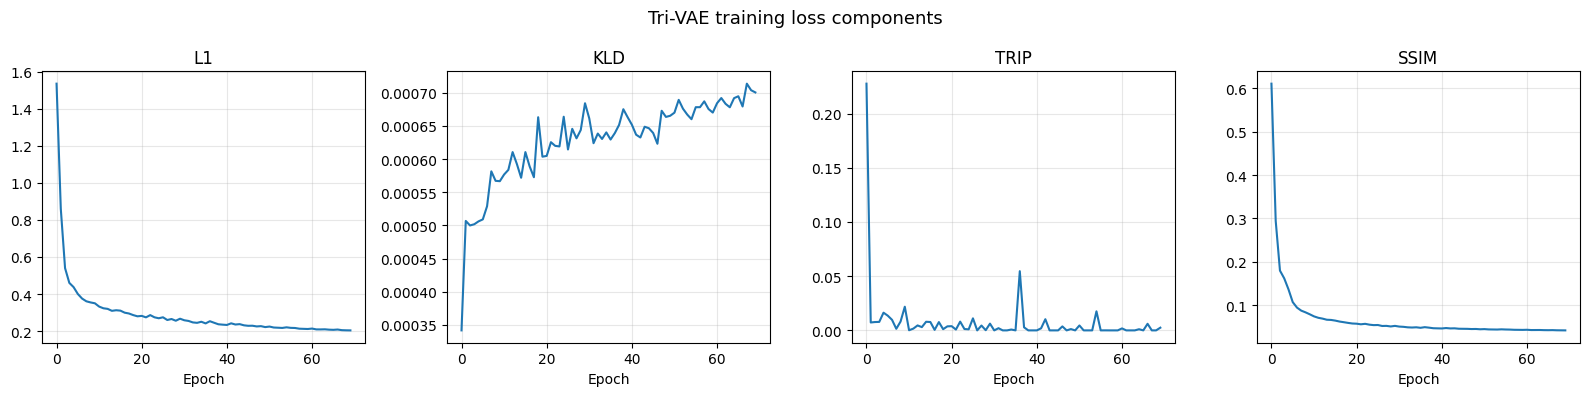

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, key in zip(axes, ['l1','kld','trip','ssim']):
    ax.plot(history[key])
    ax.set_title(key.upper())
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
plt.suptitle('Tri-VAE training loss components', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 10 — Anomaly detection inference (residual maps)

  Normal  : 1414
  Synthetic tumor: 1414
  Total   : 2828


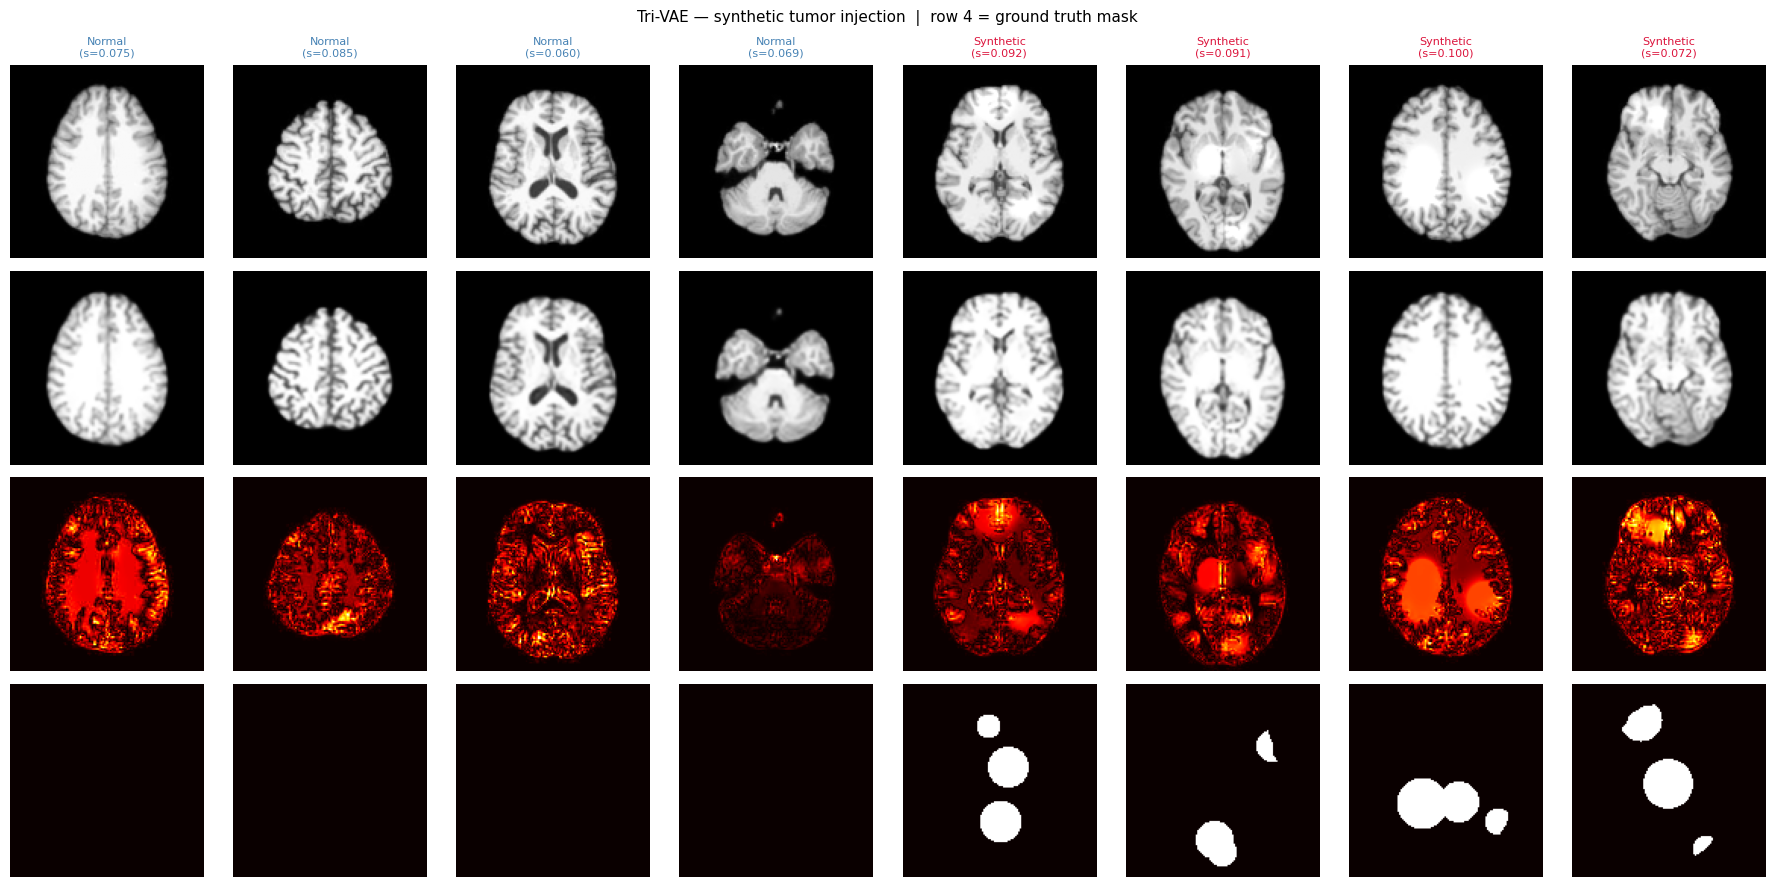

Scoring: 100%|██████████| 24/24 [00:04<00:00,  5.10it/s]


Tri-VAE — Synthetic Tumor Evaluation
─────────────────────────────────────
AUROC      : 0.9592
AUPRC      : 0.9633
Threshold  : 0.0772  (Youden J)

              precision    recall  f1-score   support

      Normal       0.89      0.91      0.90      1414
   Synthetic       0.91      0.88      0.90      1414

    accuracy                           0.90      2828
   macro avg       0.90      0.90      0.90      2828
weighted avg       0.90      0.90      0.90      2828



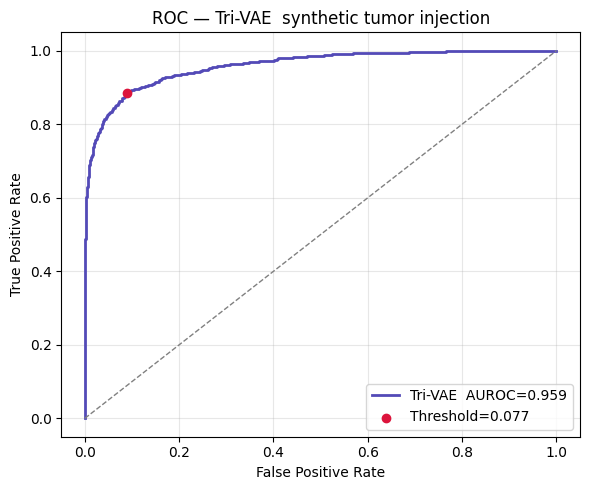

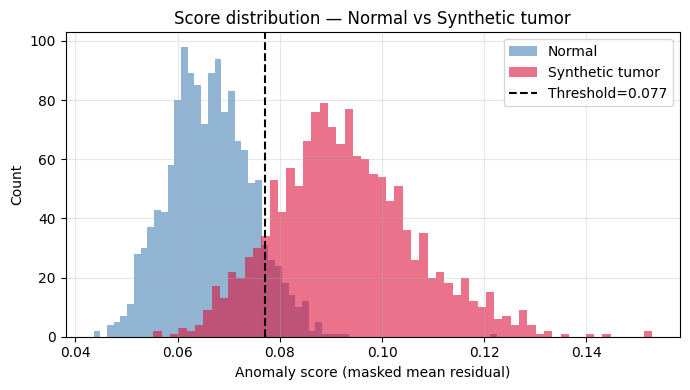

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, classification_report
from PIL import Image
import random

# ── Synthetic tumor injector ──────────────────────────────────────
def inject_tumor(img_tensor, n_blobs=3, intensity_range=(0.3, 0.8),
                 radius_range=(8, 20)):
    """
    Injects gaussian blobs onto a normalised [-1,1] tensor (1, H, W).
    Returns modified tensor + binary mask of injected region.
    """
    img = img_tensor.clone()
    _, H, W = img.shape
    mask = torch.zeros(H, W)

    # only inject inside brain — find bounding box of non-black pixels
    brain = (img[0] > -0.8)
    rows  = brain.any(dim=1).nonzero(as_tuple=True)[0]
    cols  = brain.any(dim=0).nonzero(as_tuple=True)[0]
    if len(rows) < 10 or len(cols) < 10:
        return img, mask   # empty slice — skip

    r_min, r_max = rows[0].item(), rows[-1].item()
    c_min, c_max = cols[0].item(), cols[-1].item()

    for _ in range(n_blobs):
        # random center inside brain bounding box
        cy = random.randint(r_min + 5, r_max - 5)
        cx = random.randint(c_min + 5, c_max - 5)
        radius   = random.randint(*radius_range)
        intensity = random.uniform(*intensity_range)

        # gaussian blob
        ys = torch.arange(H).float()
        xs = torch.arange(W).float()
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        dist = ((yy - cy)**2 + (xx - cx)**2).sqrt()
        blob = torch.exp(-dist**2 / (2 * (radius/2)**2))
        blob = (blob / blob.max()) * intensity

        # only apply where brain exists
        brain_float = brain.float()
        img[0] += blob * brain_float
        mask    += (blob > 0.1).float() * brain_float

    img = img.clamp(-1, 1)
    mask = (mask > 0).float()
    return img, mask


# ── Synthetic eval dataset ────────────────────────────────────────
class SyntheticTumorDataset(Dataset):
    """
    Takes healthy val images.
    50% kept as normal (label=0).
    50% get synthetic tumor blobs (label=1).
    """
    def __init__(self, val_folder, img_size=128, seed=42):
        random.seed(seed)
        torch.manual_seed(seed)

        self.tf = T.Compose([
            T.Grayscale(1),
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]),
        ])

        paths = get_image_paths(Path(val_folder))
        random.shuffle(paths)
        mid = len(paths) // 2

        self.samples = []
        for i, p in enumerate(paths):
            label = 1 if i >= mid else 0
            self.samples.append((p, label))

        print(f'  Normal  : {mid}')
        print(f'  Synthetic tumor: {len(paths)-mid}')
        print(f'  Total   : {len(paths)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self.tf(Image.open(path).convert('RGB'))
        mask = torch.zeros(img.shape[1], img.shape[2])
        if label == 1:
            img, mask = inject_tumor(img)
        return img, label, mask


# ── Build dataset & loader ────────────────────────────────────────
syn_ds = SyntheticTumorDataset('Dataset-ixi/valid/valid', img_size=IMG_SIZE)
syn_loader = DataLoader(syn_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)

# ── Helpers ───────────────────────────────────────────────────────
model.eval()

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1).cpu()

def brain_mask(img_tensor):
    return (img_tensor > -0.9).float()


# ── Visualise 4 normal + 4 synthetic tumor ────────────────────────
all_imgs   = torch.stack([s[0] for s in syn_ds])
all_labels = torch.tensor([s[1] for s in syn_ds])
all_masks  = torch.stack([s[2] for s in syn_ds])

normal_idx = (all_labels == 0).nonzero(as_tuple=True)[0][:4]
tumor_idx  = (all_labels == 1).nonzero(as_tuple=True)[0][:4]

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
row_labels = ['Input', 'Reconstruction', 'Residual map', 'GT tumor mask']

for col, idx in enumerate(list(normal_idx) + list(tumor_idx)):
    img = all_imgs[idx]
    with torch.no_grad():
        x = img.unsqueeze(0).to(DEVICE)
        mu, logvar, enc_skips = model.encode(x)
        z = model.reparameterise(mu, logvar)
        recon, _ = model.decode(z, enc_skips)
        residual = (x - recon).abs().squeeze().cpu()

    bm     = brain_mask(img)
    score  = (residual * bm).sum() / bm.sum().clamp(min=1)
    border = 'steelblue' if all_labels[idx] == 0 else 'crimson'
    title  = f'{"Normal" if all_labels[idx]==0 else "Synthetic"}\n(s={score:.3f})'

    for row, (data, cmap) in enumerate(zip(
            [denorm(img), denorm(recon.squeeze().cpu()), residual, all_masks[idx]],
            ['gray', 'gray', 'hot', 'hot'])):
        ax = axes[row, col]
        ax.imshow(data.squeeze(), cmap=cmap)
        ax.axis('off')
        if row == 0:
            ax.set_title(title, color=border, fontsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor(border)
            spine.set_linewidth(2)
            spine.set_visible(True)

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=9)

plt.suptitle('Tri-VAE — synthetic tumor injection  |  row 4 = ground truth mask',
             fontsize=11)
plt.tight_layout()
plt.show()


# ── Quantitative scoring ──────────────────────────────────────────
all_scores, all_true = [], []

with torch.no_grad():
    for imgs, labels, masks in tqdm(syn_loader, desc='Scoring'):
        imgs = imgs.to(DEVICE)
        mu, logvar, enc_skips = model.encode(imgs)
        z = model.reparameterise(mu, logvar)
        recon, _ = model.decode(z, enc_skips)

        residual = (imgs - recon).abs()
        mask     = brain_mask(imgs)
        scores   = (residual * mask).sum(dim=[1,2,3]) / \
                    mask.sum(dim=[1,2,3]).clamp(min=1)

        all_scores.extend(scores.cpu().numpy())
        all_true.extend(labels.numpy())

all_scores = np.array(all_scores)
all_true   = np.array(all_true)

auroc = roc_auc_score(all_true, all_scores)
auprc = average_precision_score(all_true, all_scores)
fpr, tpr, thresholds = roc_curve(all_true, all_scores)
best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]
preds       = (all_scores >= best_thresh).astype(int)

print(f'\nTri-VAE — Synthetic Tumor Evaluation')
print(f'─────────────────────────────────────')
print(f'AUROC      : {auroc:.4f}')
print(f'AUPRC      : {auprc:.4f}')
print(f'Threshold  : {best_thresh:.4f}  (Youden J)')
print(f'\n{classification_report(all_true, preds, target_names=["Normal","Synthetic"])}')

# ── ROC curve ─────────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='#534AB7',
         label=f'Tri-VAE  AUROC={auroc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray', lw=1)
plt.scatter(fpr[best_idx], tpr[best_idx], color='crimson', zorder=5,
            label=f'Threshold={best_thresh:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — Tri-VAE  synthetic tumor injection')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Score distribution ─────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.hist(all_scores[all_true==0], bins=60, alpha=0.6,
         color='steelblue', label='Normal')
plt.hist(all_scores[all_true==1], bins=60, alpha=0.6,
         color='crimson', label='Synthetic tumor')
plt.axvline(best_thresh, color='black', linestyle='--',
            label=f'Threshold={best_thresh:.3f}')
plt.xlabel('Anomaly score (masked mean residual)')
plt.ylabel('Count')
plt.title('Score distribution — Normal vs Synthetic tumor')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 12 — Save final model
*(We'll load this later for comparison against GAN and Diffusion)*

In [20]:
torch.save({
    'model_state': model.state_dict(),
    'config': {
        'img_size': IMG_SIZE,
        'latent_dim': LATENT_DIM,
        'base_ch': BASE_CH,
    },
    'auroc': auroc,
    'auprc': auprc,
    'history': history,
}, SAVE_DIR / 'trivae_final.pt')

print('Saved to checkpoints/trivae_final.pt')
print(f'Final AUROC: {auroc:.4f}  |  AUPRC: {auprc:.4f}')
print('\nNext: run GAN (F-AnoGAN) and Diffusion (AnoDDPM) notebooks for comparison.')

Saved to checkpoints/trivae_final.pt
Final AUROC: 0.9592  |  AUPRC: 0.9633

Next: run GAN (F-AnoGAN) and Diffusion (AnoDDPM) notebooks for comparison.
